In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("monthly_milk_production.csv")

In [3]:
df

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727
...,...,...
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797


# Data Loading & Exploration (EDA)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [5]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


In [6]:
df.shape

(168, 2)

In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)


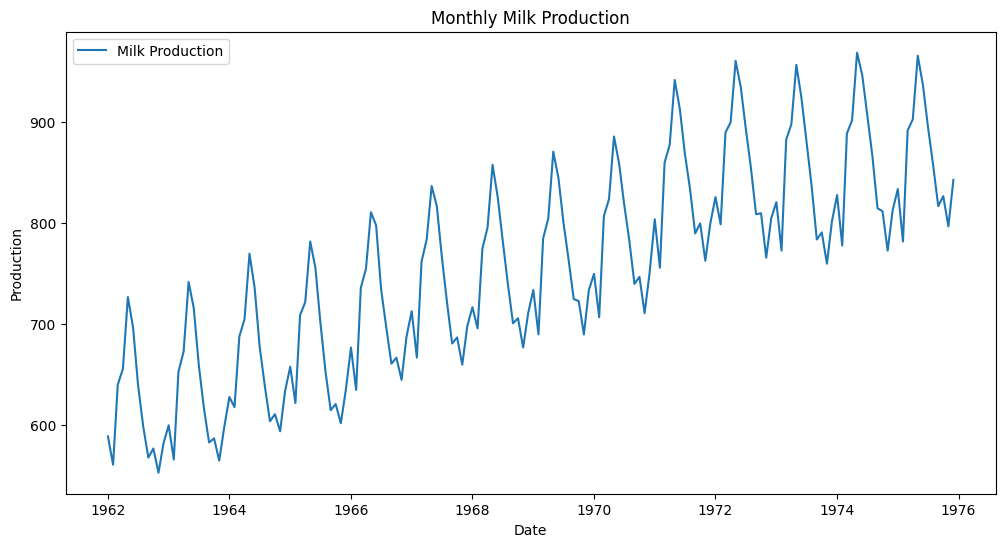

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
plt.plot(df, label="Milk Production")
plt.title("Monthly Milk Production")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.show()

In [11]:
df.isnull().sum()

Production    0
dtype: int64

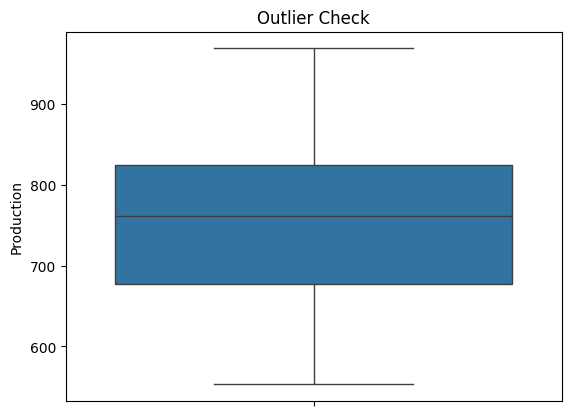

In [13]:
sns.boxplot(y=df.iloc[:,0])
plt.title("Outlier Check")
plt.show()

### Data Normalization

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

In [17]:
# Create Time Windows (Sequences)
import numpy as np
def create_sequences(data, window_size=12):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 12
X, y = create_sequences(scaled_data, window_size)


In [18]:
# Train / Validation / Test Split
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.85)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:val_size], y[train_size:val_size]
X_test, y_test = X[val_size:], y[val_size:]

In [20]:
X_train.shape  

(109, 12, 1)

# Model Building

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.optimizers import Adam

In [22]:
# RNN Model
rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(window_size, 1)),
    Dense(1)
])

rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

rnn_model.summary()


C:\Users\Yashwant\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
rnn_history = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0242 - val_loss: 0.0091
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0104 - val_loss: 0.0105
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0042 - val_loss: 0.0050
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0039 - val_loss: 0.0073
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0031 - val_loss: 0.0029
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0029 - val_loss: 0.0032
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0027 - val_loss: 0.0038
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0026 - val_loss: 0.0034
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0020 - val_loss: 0.0039
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0020 - val_loss: 0.0031
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0016 - val_loss: 0.0029
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0017 - val_loss: 0.0026
E

In [24]:
# LSTM Model
lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(window_size, 1)),
    Dense(1)
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.2004 - val_loss: 0.3113
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0810 - val_loss: 0.0840
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0286 - val_loss: 0.0294
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0341 - val_loss: 0.0265
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0267 - val_loss: 0.0349
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0261 - val_loss: 0.0400
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0258 - val_loss: 0.0321
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0247 - val_loss: 0.0297
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0245 - val_loss: 0.0277
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0242 - val_loss: 0.0279
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0238 - val_loss: 0.0284
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0242 - val_loss: 0.0311
E

In [25]:
# GRU Model
gru_model = Sequential([
    GRU(50, activation='tanh', input_shape=(window_size, 1)),
    Dense(1)
])

gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.3147 - val_loss: 0.6017
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1663 - val_loss: 0.2937
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0715 - val_loss: 0.1008
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0358 - val_loss: 0.0338
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0387 - val_loss: 0.0335
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0324 - val_loss: 0.0502
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0306 - val_loss: 0.0647
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0309 - val_loss: 0.0621
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0300 - val_loss: 0.0494
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0284 - val_loss: 0.0449
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0279 - val_loss: 0.0434
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0271 - val_loss: 0.0421
E

In [26]:
# Model Evaluation
rnn_pred = rnn_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step


In [29]:
# Inverse Scaling
y_test_inv = scaler.inverse_transform(y_test)
rnn_pred_inv = scaler.inverse_transform(rnn_pred)
lstm_pred_inv = scaler.inverse_transform(lstm_pred)
gru_pred_inv = scaler.inverse_transform(gru_pred)

In [30]:
# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

rnn_mae, rnn_rmse, rnn_mape = evaluate(y_test_inv, rnn_pred_inv)
lstm_mae, lstm_rmse, lstm_mape = evaluate(y_test_inv, lstm_pred_inv)
gru_mae, gru_rmse, gru_mape = evaluate(y_test_inv, gru_pred_inv)

In [32]:
# Performance Comparison
results = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "MAE": [rnn_mae, lstm_mae, gru_mae],
    "RMSE": [rnn_rmse, lstm_rmse, gru_rmse],
    "MAPE (%)": [rnn_mape, lstm_mape, gru_mape]
})

results


,Model,MAE,RMSE,MAPE (%)
0,RNN,11.526087,13.774706,1.362524
1,LSTM,46.354477,53.426269,5.567187
2,GRU,41.395579,47.904048,4.744098


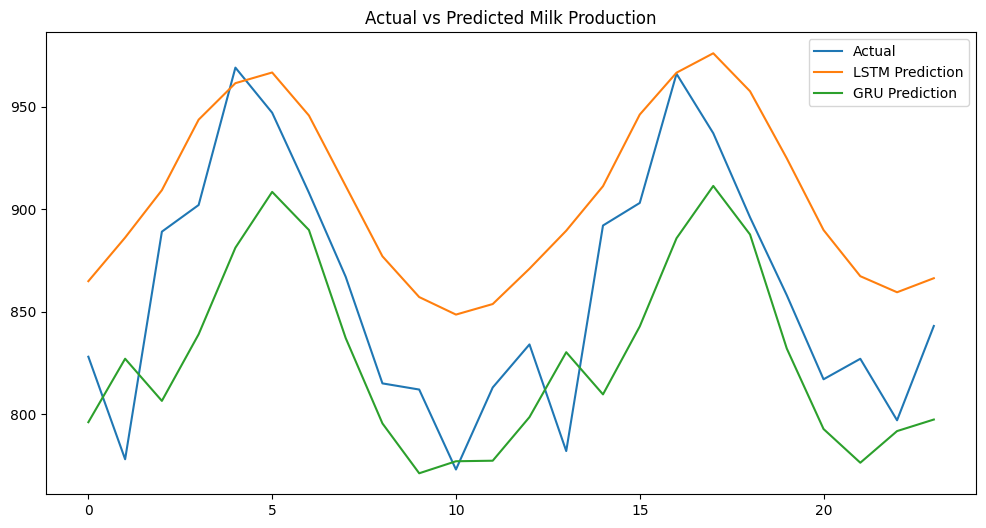

In [33]:
# Prediction vs Actual Plot
plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label="Actual")
plt.plot(lstm_pred_inv, label="LSTM Prediction")
plt.plot(gru_pred_inv, label="GRU Prediction")
plt.legend()
plt.title("Actual vs Predicted Milk Production")
plt.show()

In [34]:
# Forecast Next 12 Months (Using Best Model – LSTM)
last_window = scaled_data[-window_size:]
future_predictions = []

current_window = last_window.copy()

for _ in range(12):
    pred = lstm_model.predict(current_window.reshape(1, window_size, 1))
    future_predictions.append(pred[0,0])
    current_window = np.append(current_window[1:], pred, axis=0)

future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


C:\Users\Yashwant\AppData\Local\Temp\ipykernel_32232\3075457868.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


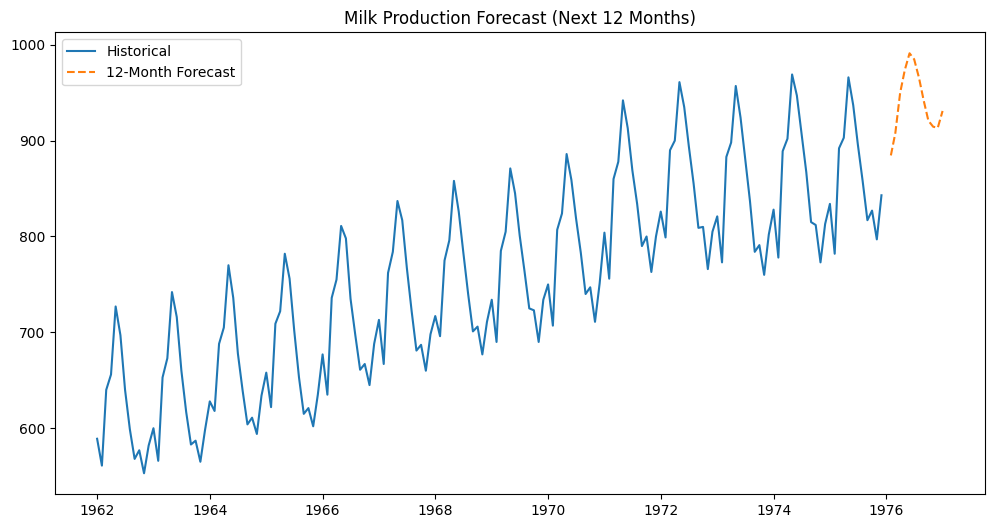

In [35]:
# Forecast Visualization
future_dates = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq='M'
)

plt.figure(figsize=(12,6))
plt.plot(df.index, df, label="Historical")
plt.plot(future_dates, future_predictions, label="12-Month Forecast", linestyle="--")
plt.legend()
plt.title("Milk Production Forecast (Next 12 Months)")
plt.show()

### Business Insights & Recommendations

#### LSTM & GRU outperform basic RNN
#### LSTM gives the lowest error
#### Strong seasonality captured by recurrent models